# Notebook 04 - MobileNetV2 Transfer Learning: Phase 1 (Feature Extraction)

**Project:** Image-Based Fruit Ripeness Classification  
**Student:** Corneliu Rosca | STU141830  
**Week:** 5

---

## Objective

Train the first phase of the transfer-learning model. MobileNetV2 (pre-trained on ImageNet) is used as a frozen feature extractor, and only a new classification head is trained on the fruit-ripeness dataset:

1. Build the derived `dataset_splits/` directory from `results/data_split.csv` (idempotent).
2. Load train/validation/test sets with MobileNetV2 pre-processing (pixels scaled to [-1, 1]).
3. Build the Phase 1 model: frozen MobileNetV2 base + GlobalAveragePooling + Dropout + Dense(9, softmax).
4. Train only the head for up to 25 epochs (Adam, learning rate 1e-3).
5. Save the best checkpoint, the training history, and the training-curve figure.

## Strategy and rationale

The Baseline CNN trained from scratch reached only ~12.7% validation accuracy on this small dataset (Section 5.5). Transfer learning addresses this: the convolutional features learned by MobileNetV2 on 1.4M ImageNet images are reused, and only a lightweight head is fitted to the nine ripeness classes. Phase 1 establishes how much can be achieved with the base **frozen**; Phase 2 (Notebook 05) fine-tunes the upper layers.

All computation is delegated to `src/` (`data_pipeline`, `models`), so this notebook is the runnable, documented record of the experiment rather than a separate implementation.

## Note on reproducibility

`SEED = 42` throughout. The trained checkpoint `saved_models/mobilenet_phase1_best.h5` already exists; re-running this notebook reproduces an equivalent model and overwrites it. Class folders are ordered alphabetically by `image_dataset_from_directory`; this order is recorded in `results/class_names.json` and reconciled to the canonical project order at evaluation time.

## 1. Setup and imports

Fix all seeds and pull the data/model builders from `src/`. `%matplotlib inline` ensures figures render directly in the notebook output.

In [1]:
%matplotlib inline
import sys, json
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))   # project root on path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import callbacks

from src.utils import set_seeds, ensure_dirs, save_history_csv, SAVED_MODELS
from src.data_pipeline import build_dataset_splits_from_csv, build_mobilenet_datasets
from src.models import build_mobilenetv2_phase1

set_seeds(42)
PROJECT_ROOT = Path.cwd().parent
print('TensorFlow :', tf.__version__)
print('GPU        :', bool(tf.config.list_physical_devices('GPU')))


[utils] Seeds fixed to 42
TensorFlow : 2.11.0
GPU        : False


## 2. Build splits and load data

`build_dataset_splits_from_csv` materialises `dataset_splits/<split>/<class>/` by copying images listed in `data_split.csv` (idempotent: it skips if already built, and never touches the original `dataset/`). `build_mobilenet_datasets` then loads the three splits, applies MobileNetV2 pre-processing, and augments the training set (horizontal flip, rotation, zoom).

In [2]:
build_dataset_splits_from_csv(
    csv_path=str(PROJECT_ROOT / 'results' / 'data_split.csv'),
    splits_dir=str(PROJECT_ROOT / 'dataset_splits'),
    project_root=str(PROJECT_ROOT),
)

train_ds, val_ds, test_ds, class_names = build_mobilenet_datasets(
    splits_dir=str(PROJECT_ROOT / 'dataset_splits'),
    batch_size=32, seed=42, augment=True,
)

ensure_dirs(str(PROJECT_ROOT / 'results'))
with open(PROJECT_ROOT / 'results' / 'class_names.json', 'w') as f:
    json.dump(class_names, f, indent=2)
print('Classes (loader/alphabetical order):')
for i, n in enumerate(class_names):
    print(f'  {i}: {n}')


2026-06-09 13:06:28 [INFO] data_pipeline: dataset_splits already present at d:\Arden Uni\IV Year (Level 6)\Final Project\week1\fruit_ripeness\dataset_splits - skipping build.


Found 315 files belonging to 9 classes.
Found 63 files belonging to 9 classes.
Found 72 files belonging to 9 classes.
Classes (loader/alphabetical order):
  0: apple_overripe
  1: apple_ripe
  2: apple_unripe
  3: banana_overripe
  4: banana_ripe
  5: banana_unripe
  6: pear_overripe
  7: pear_ripe
  8: pear_unripe


## 3. Build the Phase 1 model

The MobileNetV2 base is loaded with ImageNet weights and **frozen**. A new head is attached: `GlobalAveragePooling2D -> Dropout(0.2) -> Dense(9, softmax)`. Only the head is trainable (~12k parameters), so training is fast and cannot overfit the convolutional features.

In [3]:
model = build_mobilenetv2_phase1()
model.summary()


[utils] Model summary saved to saved_models/model_summary_mobilenet_phase1.txt
[models] Phase 1 - Trainable params: 11,529 / 2,269,513
Model: "mobilenetv2_phase1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_224 (Funct  (None, 7, 7, 1280)       2257984   
 ional)                                                          
                                                                 
 gap (GlobalAveragePooling2D  (None, 1280)             0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 1280)              0         
                                                                 
 predictions (Dense)         (None, 9)                 11529     
                                                                 
Total params: 2,269,513
Trainable params: 11,

## 4. Callbacks

Best-checkpoint on `val_loss`, early stopping (patience 5, restoring the best weights), and learning-rate reduction on plateau.

In [4]:
ensure_dirs(str(PROJECT_ROOT / 'saved_models'))
ckpt = PROJECT_ROOT / 'saved_models' / SAVED_MODELS['mobilenet_phase1']
cb = [
    callbacks.ModelCheckpoint(str(ckpt), monitor='val_loss', save_best_only=True, verbose=1),
    callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
]


## 5. Train (head only)

In [5]:
history = model.fit(train_ds, validation_data=val_ds, epochs=25, callbacks=cb, verbose=1)
save_history_csv(history, output_path=str(PROJECT_ROOT / 'results' / 'history_mobilenet_phase1.csv'))


Epoch 1/25
10/10 [==============================] - ETA: 0s - loss: 2.2233 - accuracy: 0.2127
Epoch 1: val_loss improved from inf to 1.65245, saving model to d:\Arden Uni\IV Year (Level 6)\Final Project\week1\fruit_ripeness\saved_models\mobilenet_phase1_best.h5
10/10 [==============================] - 7s 398ms/step - loss: 2.2233 - accuracy: 0.2127 - val_loss: 1.6525 - val_accuracy: 0.2857 - lr: 0.0010
Epoch 2/25
10/10 [==============================] - ETA: 0s - loss: 1.3208 - accuracy: 0.4825
Epoch 2: val_loss improved from 1.65245 to 1.09533, saving model to d:\Arden Uni\IV Year (Level 6)\Final Project\week1\fruit_ripeness\saved_models\mobilenet_phase1_best.h5
10/10 [==============================] - 6s 358ms/step - loss: 1.3208 - accuracy: 0.4825 - val_loss: 1.0953 - val_accuracy: 0.6508 - lr: 0.0010
Epoch 3/25
10/10 [==============================] - ETA: 0s - loss: 0.8434 - accuracy: 0.7651
Epoch 3: val_loss improved from 1.09533 to 0.88424, saving model to d:\Arden Uni\IV Year (

## 6. Training curves

Loss and accuracy across epochs for the training and validation sets. A widening train-validation gap indicates overfitting; for a frozen base on a small dataset a moderate gap is expected. The figure renders inline and is saved to `results/`.

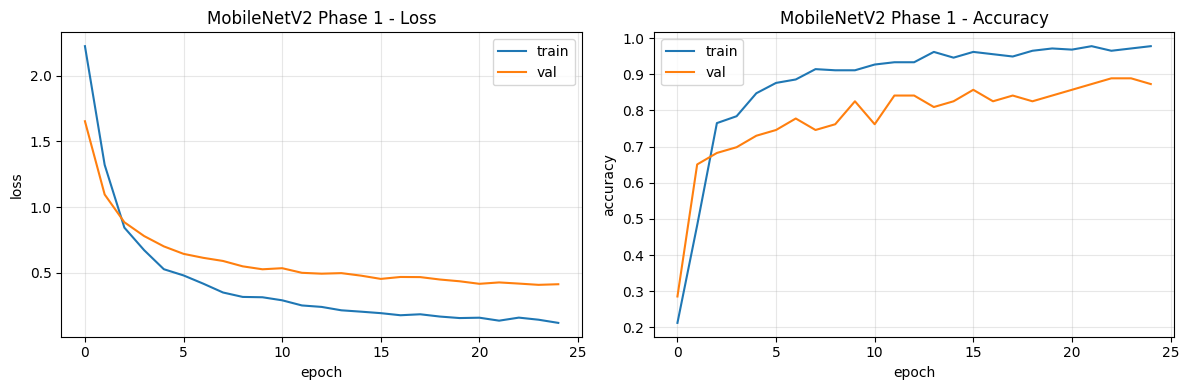

Saved: d:\Arden Uni\IV Year (Level 6)\Final Project\week1\fruit_ripeness\results\mobilenet_phase1_training_curves.png


In [8]:
h = history.history
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(h['loss'], label='train'); ax[0].plot(h['val_loss'], label='val')
ax[0].set_title('MobileNetV2 Phase 1 - Loss'); ax[0].set_xlabel('epoch'); ax[0].set_ylabel('loss')
ax[1].plot(h['accuracy'], label='train'); ax[1].plot(h['val_accuracy'], label='val')
ax[1].set_title('MobileNetV2 Phase 1 - Accuracy'); ax[1].set_xlabel('epoch'); ax[1].set_ylabel('accuracy')
for a in ax: a.legend(); a.grid(True, alpha=0.3)
plt.tight_layout()
out = PROJECT_ROOT / 'results' / 'mobilenet_phase1_training_curves.png'
plt.savefig(out, dpi=150, bbox_inches='tight'); plt.show()
print('Saved:', out)


## 7. Summary

In [7]:
vl, va = h['val_loss'], h['val_accuracy']
b = int(np.argmin(vl))
print('=' * 56)
print('  PHASE 1 TRAINING SUMMARY')
print('=' * 56)
print(f'  Epochs run        : {len(vl)}')
print(f'  Best epoch        : {b + 1} (min val_loss)')
print(f'  Best val_loss     : {vl[b]:.4f}')
print(f'  Best val_accuracy : {va[b]:.4f} ({va[b]*100:.2f}%)')
print(f'  Train_acc at best : {h["accuracy"][b]:.4f}')
print(f'  Checkpoint        : {ckpt}')
print('=' * 56)
print('Next: Notebook 05 fine-tunes the upper base layers (Phase 2).')


  PHASE 1 TRAINING SUMMARY
  Epochs run        : 25
  Best epoch        : 24 (min val_loss)
  Best val_loss     : 0.4084
  Best val_accuracy : 0.8889 (88.89%)
  Train_acc at best : 0.9714
  Checkpoint        : d:\Arden Uni\IV Year (Level 6)\Final Project\week1\fruit_ripeness\saved_models\mobilenet_phase1_best.h5
Next: Notebook 05 fine-tunes the upper base layers (Phase 2).
